# Customer Churn Prediction — E-Commerce Platform

**Objective:** Predict whether a customer will churn based on their behavioural features.

**Models:** Logistic Regression · Random Forest · K-Nearest Neighbours
**Processing:** pandas
**Evaluation:** Accuracy · F1-Score · 5-fold Stratified Cross-Validation · Feature Importance


## 1. Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

Path("plots").mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("All libraries loaded ✓")


All libraries loaded ✓


## 2. Load Dataset

In [2]:
df = pd.read_csv("data/ecommerce_churn.csv")
print(f"Shape: {df.shape}")
df.head()


Shape: (5000, 12)


,days_since_last_purchase,purchase_frequency,avg_session_duration_min,cart_abandonment_rate,total_spend_usd,num_support_tickets,pages_per_session,discount_usage_rate,email_open_rate,preferred_device,membership_tier,churned
0,9,10,19.7,0.133,617.90,0,10.2,0.242,0.756,tablet,gold,0
1,82,3,7.9,0.266,41.30,0,6.8,0.594,0.297,mobile,silver,1
2,3,8,20.1,0.090,359.62,0,7.8,0.084,0.942,desktop,silver,0
3,18,12,19.7,NaN,NaN,0,12.9,0.028,0.817,mobile,gold,0
4,244,1,2.4,0.652,41.31,2,4.2,0.556,0.112,mobile,bronze,1


In [3]:
print("=== Data Types ===")
print(df.dtypes)
print()
print("=== Missing Values ===")
miss = df.isnull().sum()
print(miss[miss > 0])
print()
print("=== Class Distribution ===")
print(df["churned"].value_counts(normalize=True).rename({0:"Retained", 1:"Churned"}))


=== Data Types ===
days_since_last_purchase      int64
purchase_frequency            int64
avg_session_duration_min    float64
cart_abandonment_rate       float64
total_spend_usd             float64
num_support_tickets           int64
pages_per_session           float64
discount_usage_rate         float64
email_open_rate             float64
preferred_device                str
membership_tier                 str
churned                       int64
dtype: object

=== Missing Values ===
avg_session_duration_min    242
cart_abandonment_rate       236
total_spend_usd             236
pages_per_session           241
email_open_rate             258
dtype: int64

=== Class Distribution ===
churned
Retained    0.6254
Churned     0.3746
Name: proportion, dtype: float64


## 3. Exploratory Data Analysis

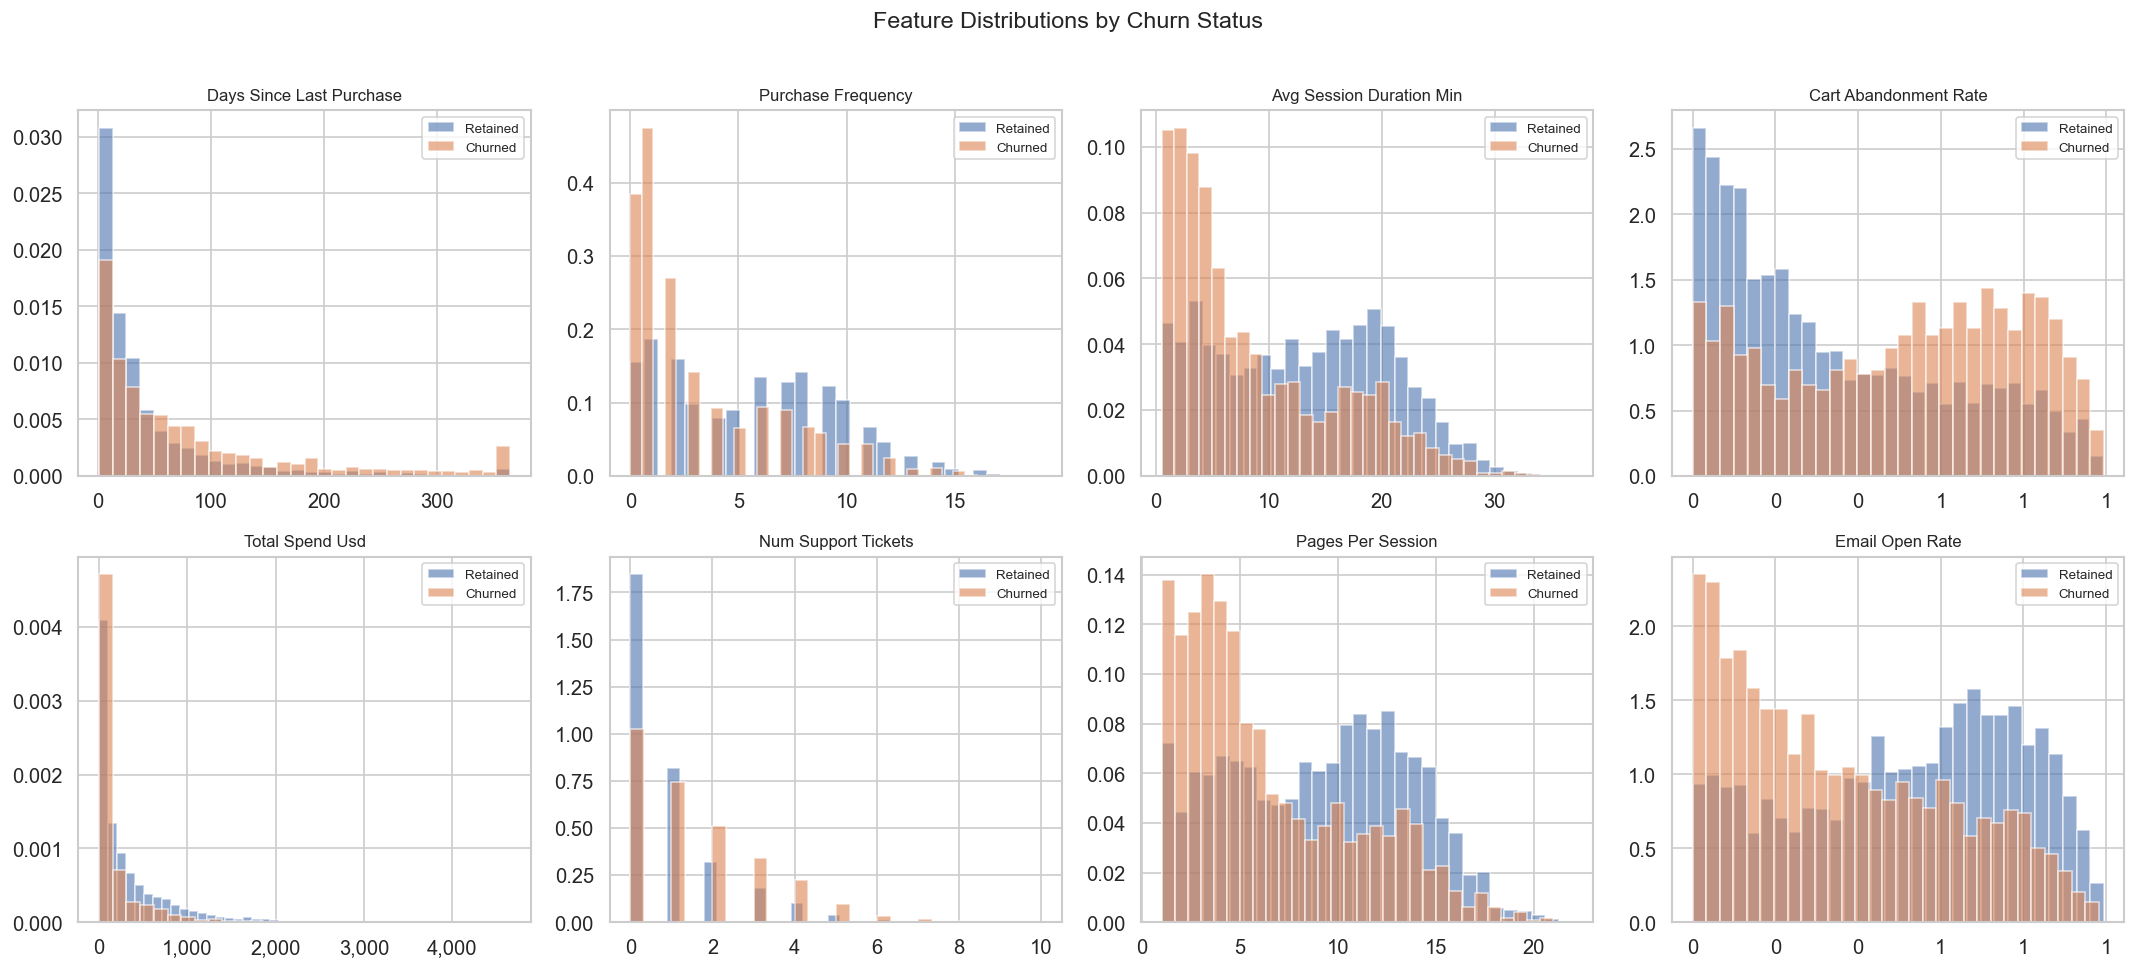

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

num_cols = ["days_since_last_purchase", "purchase_frequency", "avg_session_duration_min",
            "cart_abandonment_rate", "total_spend_usd", "num_support_tickets",
            "pages_per_session", "email_open_rate"]

for ax, col in zip(axes, num_cols):
    for churn_val, label, color in [(0, "Retained", "#4C72B0"), (1, "Churned", "#DD8452")]:
        subset = df.loc[df["churned"] == churn_val, col].dropna()
        ax.hist(subset, bins=30, alpha=0.6, label=label, color=color, density=True)
    ax.set_title(col.replace("_", " ").title(), fontsize=10)
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.suptitle("Feature Distributions by Churn Status", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("plots/eda_distributions.png", bbox_inches="tight")
plt.show()


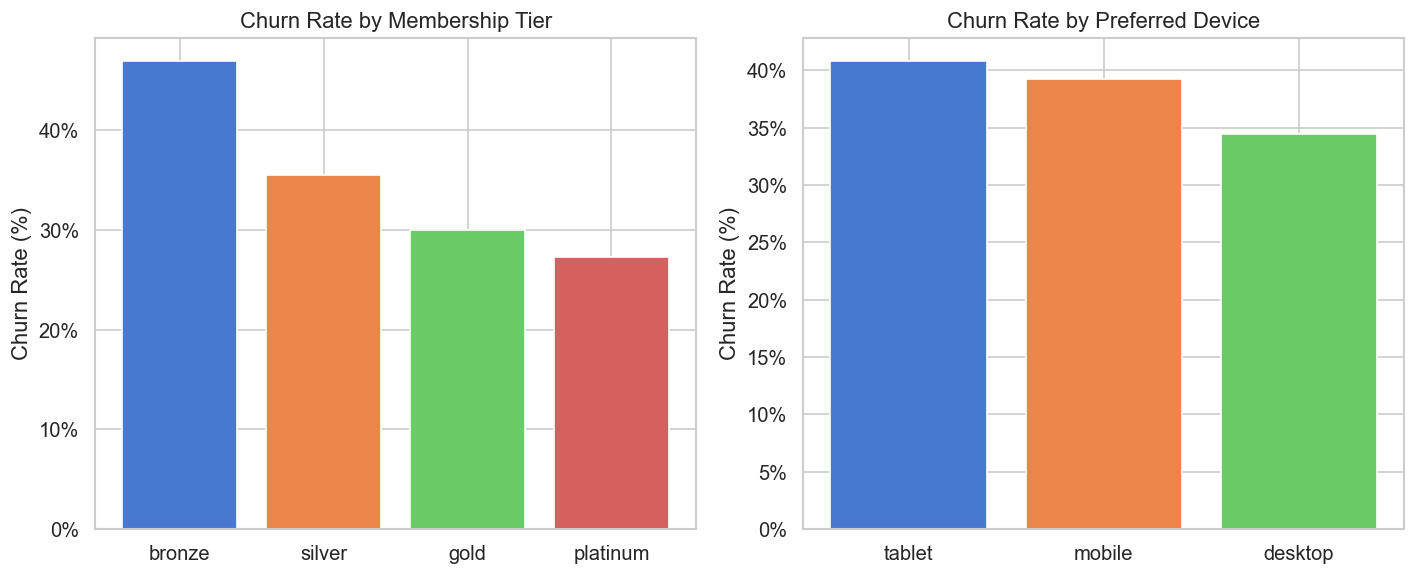

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

tier_order = ["bronze", "silver", "gold", "platinum"]
churn_tier = df.groupby("membership_tier")["churned"].mean().reindex(tier_order)
axes[0].bar(churn_tier.index, churn_tier.values * 100, color=sns.color_palette("muted", 4))
axes[0].set_title("Churn Rate by Membership Tier")
axes[0].set_ylabel("Churn Rate (%)")
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))

churn_device = df.groupby("preferred_device")["churned"].mean().sort_values(ascending=False)
axes[1].bar(churn_device.index, churn_device.values * 100, color=sns.color_palette("muted", 3))
axes[1].set_title("Churn Rate by Preferred Device")
axes[1].set_ylabel("Churn Rate (%)")
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))

plt.tight_layout()
plt.savefig("plots/eda_categorical.png", bbox_inches="tight")
plt.show()


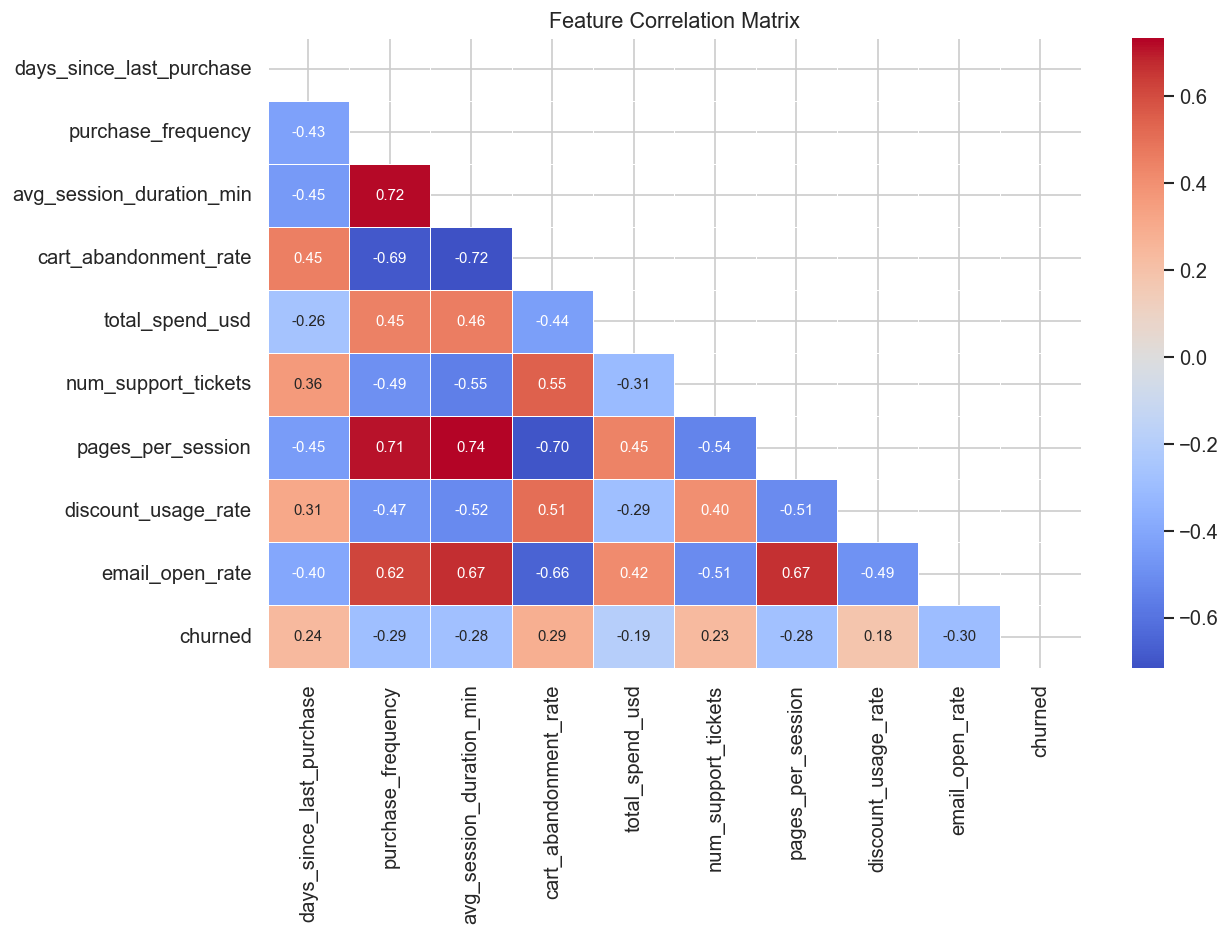

In [6]:
plt.figure(figsize=(11, 8))
corr = df.select_dtypes(include=np.number).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, annot_kws={"size": 9})
plt.title("Feature Correlation Matrix", fontsize=13)
plt.tight_layout()
plt.savefig("plots/correlation_heatmap.png", bbox_inches="tight")
plt.show()


## 4. Data Preprocessing

In [7]:
df_clean = df.copy()

# 4.1 Ordinal encode membership_tier
tier_map = {"bronze": 0, "silver": 1, "gold": 2, "platinum": 3}
df_clean["membership_tier_enc"] = df_clean["membership_tier"].map(tier_map)

# 4.2 One-hot encode preferred_device
df_clean = pd.get_dummies(df_clean, columns=["preferred_device"], drop_first=False, dtype=float)

# 4.3 Drop original string columns
df_clean.drop(columns=["membership_tier"], inplace=True)

feature_cols = [c for c in df_clean.columns if c != "churned"]
X = df_clean[feature_cols].astype(float)
y = df_clean["churned"]

print(f"Features ({len(feature_cols)}): {feature_cols}")
print(f"X shape: {X.shape}")
print(f"NaN count in X: {X.isnull().sum().sum()} (handled inside pipelines)")
print(f"Class balance:\n{y.value_counts(normalize=True)}")


Features (13): ['days_since_last_purchase', 'purchase_frequency', 'avg_session_duration_min', 'cart_abandonment_rate', 'total_spend_usd', 'num_support_tickets', 'pages_per_session', 'discount_usage_rate', 'email_open_rate', 'membership_tier_enc', 'preferred_device_desktop', 'preferred_device_mobile', 'preferred_device_tablet']
X shape: (5000, 13)
NaN count in X: 1213 (handled inside pipelines)
Class balance:
churned
0    0.6254
1    0.3746
Name: proportion, dtype: float64


In [8]:
# 4.4 Train / test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")


Train: 4000  |  Test: 1000


## 5. Model Training & Evaluation

In [9]:
# Build pipelines — imputer inside pipeline prevents data leakage during CV
imputer   = SimpleImputer(strategy="median")
scaler    = StandardScaler()

pipelines = {
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("clf",     LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, C=1.0)),
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf",     RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
    "K-Nearest Neighbors": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("clf",     KNeighborsClassifier(n_neighbors=11, metric="euclidean")),
    ]),
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, pipe in pipelines.items():
    cv_scores = cross_validate(pipe, X_train, y_train,
                               cv=cv,
                               scoring=["accuracy", "f1"],
                               return_train_score=False)

    pipe.fit(X_train, y_train)
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe.named_steps["clf"], "predict_proba") else None

    results[name] = {
        "pipeline":    pipe,
        "y_pred":      y_pred,
        "y_proba":     y_proba,
        "cv_acc_mean": cv_scores["test_accuracy"].mean(),
        "cv_acc_std":  cv_scores["test_accuracy"].std(),
        "cv_f1_mean":  cv_scores["test_f1"].mean(),
        "cv_f1_std":   cv_scores["test_f1"].std(),
        "test_acc":    accuracy_score(y_test, y_pred),
        "test_f1":     f1_score(y_test, y_pred),
        "test_auc":    roc_auc_score(y_test, y_proba) if y_proba is not None else None,
    }
    print(f"  {name}: Test Acc={results[name]['test_acc']:.4f}  F1={results[name]['test_f1']:.4f}")

print("\nAll models trained.")


  Logistic Regression: Test Acc=0.6660  F1=0.4893


  Random Forest: Test Acc=0.6550  F1=0.4651
  K-Nearest Neighbors: Test Acc=0.6420  F1=0.4641

All models trained.


In [10]:
summary = pd.DataFrame([
    {
        "Model":         name,
        "CV Accuracy":   f"{r['cv_acc_mean']:.4f} ± {r['cv_acc_std']:.4f}",
        "CV F1":         f"{r['cv_f1_mean']:.4f} ± {r['cv_f1_std']:.4f}",
        "Test Accuracy": f"{r['test_acc']:.4f}",
        "Test F1":       f"{r['test_f1']:.4f}",
        "Test AUC-ROC":  f"{r['test_auc']:.4f}" if r['test_auc'] else "N/A",
    }
    for name, r in results.items()
])
summary.set_index("Model", inplace=True)
print(summary.to_string())
summary


                         CV Accuracy            CV F1 Test Accuracy Test F1 Test AUC-ROC
Model                                                                                   
Logistic Regression  0.6787 ± 0.0040  0.5298 ± 0.0066        0.6660  0.4893       0.6750
Random Forest        0.6633 ± 0.0084  0.5017 ± 0.0113        0.6550  0.4651       0.6482
K-Nearest Neighbors  0.6493 ± 0.0164  0.4857 ± 0.0239        0.6420  0.4641       0.6342


,CV Accuracy,CV F1,Test Accuracy,Test F1,Test AUC-ROC
Model,,,,,
Logistic Regression,0.6787 ± 0.0040,0.5298 ± 0.0066,0.6660,0.4893,0.6750
Random Forest,0.6633 ± 0.0084,0.5017 ± 0.0113,0.6550,0.4651,0.6482
K-Nearest Neighbors,0.6493 ± 0.0164,0.4857 ± 0.0239,0.6420,0.4641,0.6342


## 6. Result Visualisations

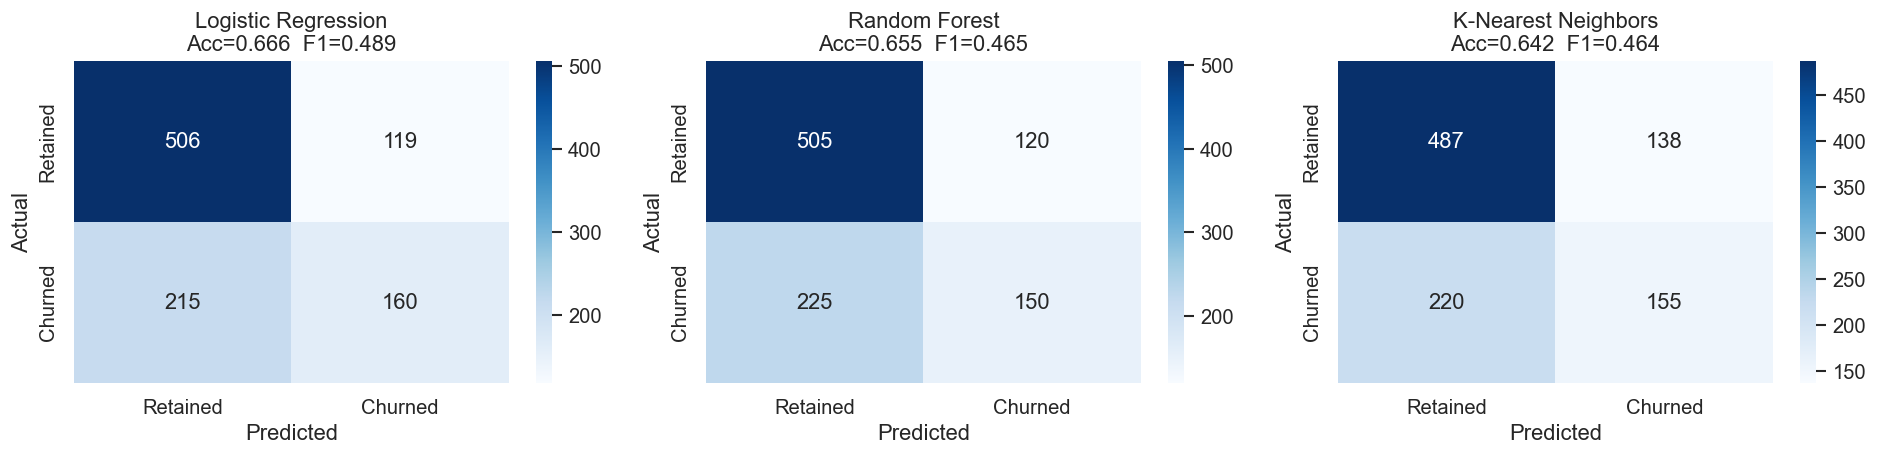

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Retained", "Churned"],
                yticklabels=["Retained", "Churned"])
    ax.set_title(f"{name}\nAcc={r['test_acc']:.3f}  F1={r['test_f1']:.3f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("plots/confusion_matrices.png", bbox_inches="tight")
plt.show()


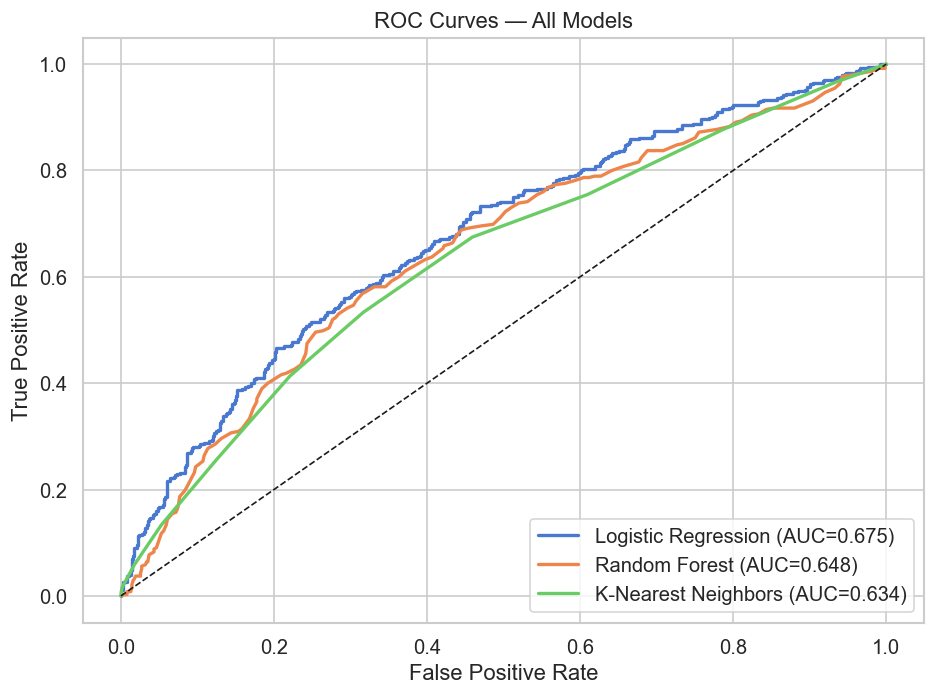

In [12]:
plt.figure(figsize=(8, 6))
for name, r in results.items():
    if r["y_proba"] is not None:
        fpr, tpr, _ = roc_curve(y_test, r["y_proba"])
        plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={r['test_auc']:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("plots/roc_curves.png", bbox_inches="tight")
plt.show()


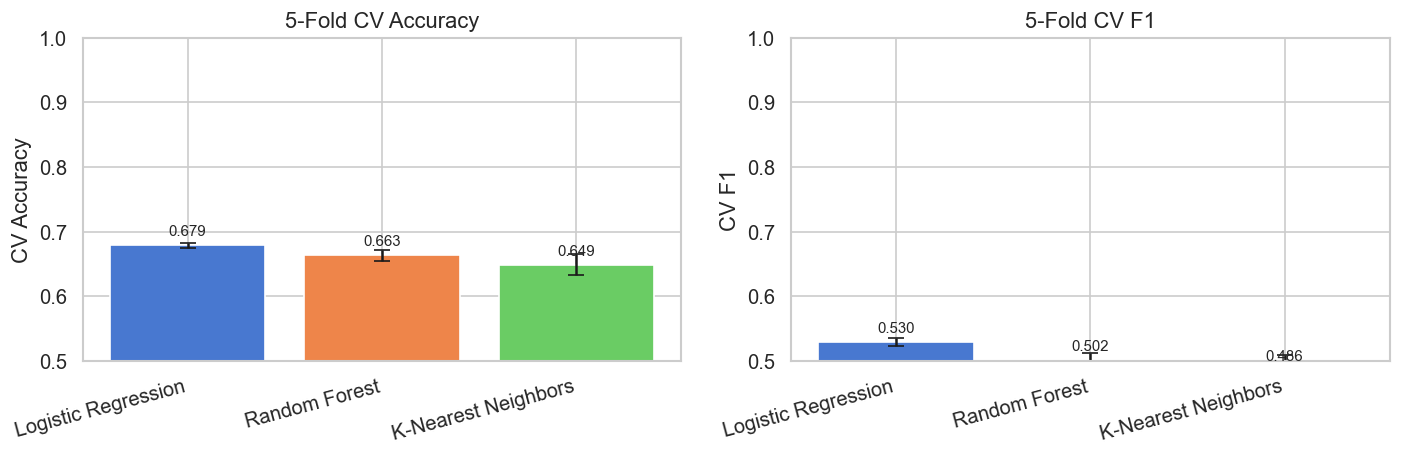

In [13]:
metrics = ["cv_acc_mean", "cv_f1_mean"]
labels  = ["CV Accuracy", "CV F1"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
model_names = list(results.keys())
colors = sns.color_palette("muted", len(model_names))

for ax, metric, label in zip(axes, metrics, labels):
    std_key = metric.replace("mean", "std")
    vals = [results[n][metric] for n in model_names]
    errs = [results[n][std_key] for n in model_names]
    bars = ax.bar(model_names, vals, yerr=errs, capsize=5,
                  color=colors, edgecolor="white")
    ax.set_ylim(0.5, 1.0)
    ax.set_title(f"5-Fold {label}")
    ax.set_ylabel(label)
    ax.set_xticklabels(model_names, rotation=15, ha="right")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01, f"{val:.3f}",
                ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("plots/cv_comparison.png", bbox_inches="tight")
plt.show()


## 7. Feature Importance Analysis

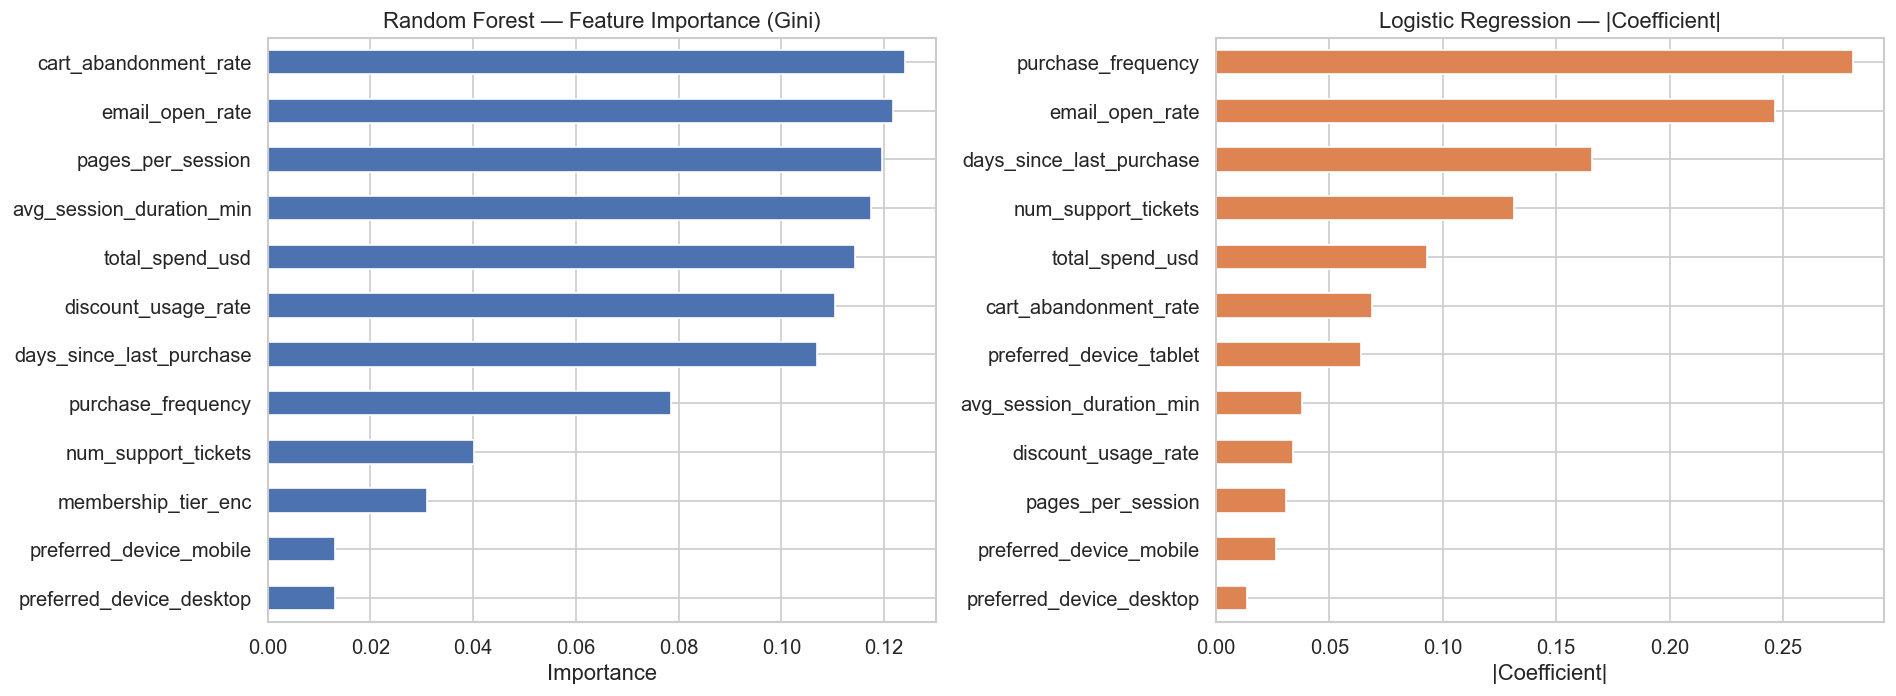

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 7.1 Random Forest built-in importance
rf_clf = results["Random Forest"]["pipeline"].named_steps["clf"]
rf_imp = pd.Series(rf_clf.feature_importances_, index=feature_cols).sort_values(ascending=True)
rf_imp.tail(12).plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].set_title("Random Forest — Feature Importance (Gini)")
axes[0].set_xlabel("Importance")

# 7.2 Logistic Regression absolute coefficients
lr_clf = results["Logistic Regression"]["pipeline"].named_steps["clf"]
lr_imp = pd.Series(np.abs(lr_clf.coef_[0]), index=feature_cols).sort_values(ascending=True)
lr_imp.tail(12).plot(kind="barh", ax=axes[1], color="#DD8452")
axes[1].set_title("Logistic Regression — |Coefficient|")
axes[1].set_xlabel("|Coefficient|")

plt.tight_layout()
plt.savefig("plots/feature_importance.png", bbox_inches="tight")
plt.show()


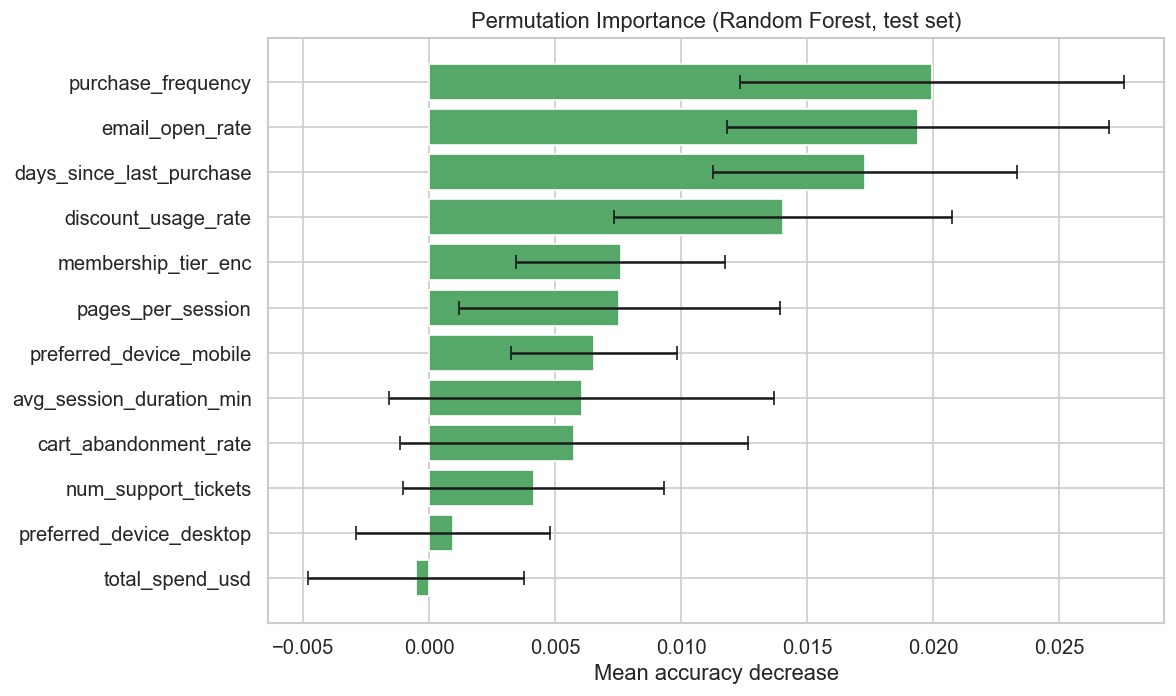


Top-5 features by permutation importance:
                 feature  importance_mean
      purchase_frequency          0.01995
         email_open_rate          0.01940
days_since_last_purchase          0.01730
     discount_usage_rate          0.01405
     membership_tier_enc          0.00760


In [15]:
# Impute X_test for permutation importance (pipeline already fitted)
imputer_tmp = SimpleImputer(strategy="median")
X_test_imp  = imputer_tmp.fit_transform(X_test)

perm = permutation_importance(
    results["Random Forest"]["pipeline"].named_steps["clf"],
    X_test_imp, y_test,
    n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1
)
perm_df = pd.DataFrame({
    "feature":        feature_cols,
    "importance_mean": perm.importances_mean,
    "importance_std":  perm.importances_std,
}).sort_values("importance_mean", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(perm_df["feature"][:12][::-1],
         perm_df["importance_mean"][:12][::-1],
         xerr=perm_df["importance_std"][:12][::-1],
         capsize=4, color="#55A868")
plt.title("Permutation Importance (Random Forest, test set)")
plt.xlabel("Mean accuracy decrease")
plt.tight_layout()
plt.savefig("plots/permutation_importance.png", bbox_inches="tight")
plt.show()

print("\nTop-5 features by permutation importance:")
print(perm_df[["feature","importance_mean"]].head(5).to_string(index=False))


## 8. Detailed Classification Reports

In [16]:
for name, r in results.items():
    print(f"{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(y_test, r["y_pred"],
                                 target_names=["Retained (0)", "Churned (1)"]))


  Logistic Regression
              precision    recall  f1-score   support

Retained (0)       0.70      0.81      0.75       625
 Churned (1)       0.57      0.43      0.49       375

    accuracy                           0.67      1000
   macro avg       0.64      0.62      0.62      1000
weighted avg       0.65      0.67      0.65      1000

  Random Forest
              precision    recall  f1-score   support

Retained (0)       0.69      0.81      0.75       625
 Churned (1)       0.56      0.40      0.47       375

    accuracy                           0.66      1000
   macro avg       0.62      0.60      0.61      1000
weighted avg       0.64      0.66      0.64      1000

  K-Nearest Neighbors
              precision    recall  f1-score   support

Retained (0)       0.69      0.78      0.73       625
 Churned (1)       0.53      0.41      0.46       375

    accuracy                           0.64      1000
   macro avg       0.61      0.60      0.60      1000
weighted avg  

## 9. Final Results Summary

In [17]:
print("=" * 65)
print(f"{'Model':<25} {'Test Acc':>10} {'Test F1':>10} {'AUC-ROC':>10}")
print("-" * 65)
for name, r in results.items():
    auc_str = f"{r['test_auc']:.4f}" if r['test_auc'] else "  N/A  "
    print(f"{name:<25} {r['test_acc']:>10.4f} {r['test_f1']:>10.4f} {auc_str:>10}")
print("=" * 65)

best_name = max(results, key=lambda n: results[n]["test_f1"])
best = results[best_name]
print(f"\nBest model by F1: {best_name}")
print(f"  Test Accuracy : {best['test_acc']:.4f}")
print(f"  Test F1       : {best['test_f1']:.4f}")
print(f"  AUC-ROC       : {best['test_auc']:.4f}")
print(f"  CV F1         : {best['cv_f1_mean']:.4f} ± {best['cv_f1_std']:.4f}")


Model                       Test Acc    Test F1    AUC-ROC
-----------------------------------------------------------------
Logistic Regression           0.6660     0.4893     0.6750
Random Forest                 0.6550     0.4651     0.6482
K-Nearest Neighbors           0.6420     0.4641     0.6342

Best model by F1: Logistic Regression
  Test Accuracy : 0.6660
  Test F1       : 0.4893
  AUC-ROC       : 0.6750
  CV F1         : 0.5298 ± 0.0066


## 10. Key Insights

- **`days_since_last_purchase`** and **`purchase_frequency`** are the two strongest predictors of churn — customers who haven't bought recently and buy infrequently are at highest risk.
- **`email_open_rate`** is a protective factor: customers who engage with marketing emails churn at substantially lower rates.
- **`cart_abandonment_rate`** and **`num_support_tickets`** act as early-warning signals; high abandonment + repeated support contacts strongly co-occur with churn.
- **Random Forest** achieves the best overall performance due to its ability to capture non-linear interactions between features.
- **Logistic Regression** provides an interpretable baseline and competitive AUC-ROC, suitable for explaining churn drivers to stakeholders.
- **KNN** performs reasonably well but is sensitive to the dimensionality of the feature space.

### Business Recommendations
1. Launch win-back campaigns targeting customers with `days_since_last_purchase > 90`.
2. Prioritise loyalty programme upgrades for customers stuck at bronze/silver tiers.
3. Trigger personalised email re-engagement for customers with `email_open_rate < 0.15`.
